In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/train.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/sampleSubmission.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/stores.csv
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/features.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/test.csv.zip


In [4]:
%pip install -q dagshub mlflow


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 89.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 88.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [6]:
import dagshub
dagshub.init(repo_owner='izere23', repo_name='ML-Final-Walmart-Recruiting-Store-Sales-Forecasting', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=3c59c963-3f1c-441d-860b-1d7ad72dfdd5&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=1cbf91fc3331cbd20ab1464289e8d3d88df98b112dceb1121dcef2fb8938111b




Accessing as gvakh23

Initialized MLflow to track repo "izere23/ML-Final-Walmart-Recruiting-Store-Sales-Forecasting"

Repository izere23/ML-Final-Walmart-Recruiting-Store-Sales-Forecasting initialized!

In [7]:
import mlflow
print(mlflow.get_tracking_uri())

https://dagshub.com/izere23/ML-Final-Walmart-Recruiting-Store-Sales-Forecasting.mlflow


In [8]:
DATA_DIR = "/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting"

In [9]:
train = pd.read_csv(f"{DATA_DIR}/train.csv.zip")
test = pd.read_csv(f"{DATA_DIR}/test.csv.zip")
features = pd.read_csv(f"{DATA_DIR}/features.csv.zip")
stores = pd.read_csv(f"{DATA_DIR}/stores.csv")
sample_submission = pd.read_csv(f"{DATA_DIR}/sampleSubmission.csv.zip")

print("train:", train.shape)
print("test:", test.shape)
print("features:", features.shape)
print("stores:", stores.shape)
print("sample_submission:", sample_submission.shape)

train: (421570, 5)
test: (115064, 4)
features: (8190, 12)
stores: (45, 3)
sample_submission: (115064, 2)


# Date სვეტის datetime ფორმატში გადაყვანა

ამ cell-ში `Date` სვეტი ტექსტიდან ნამდვილ თარიღად (`datetime`) გარდაიქმნება.
თარიღი უბრალო string არ უნდა იყოს, რადგან გვჭირდება წელი, თვე, კვირა, სეზონურობა და დროითი split.


In [10]:
for df in [train, test, features]:
    df["Date"] = pd.to_datetime(df["Date"])

# Train/Test/Features date range-ის შემოწმება
ეს cell აჩვენებს, რა პერიოდს ფარავს თითოეული ცხრილი.


In [11]:
print("Train date range:")
print(train["Date"].min(), "→", train["Date"].max())

print("\nTest date range:")
print(test["Date"].min(), "→", test["Date"].max())

print("\nFeatures date range:")
print(features["Date"].min(), "→", features["Date"].max())


Train date range:
2010-02-05 00:00:00 → 2012-10-26 00:00:00

Test date range:
2012-11-02 00:00:00 → 2013-07-26 00:00:00

Features date range:
2010-02-05 00:00:00 → 2013-07-26 00:00:00


# ცხრილების სტრუქტურა

In [12]:
for name, df in {
    "train": train,
    "test": test,
    "features": features,
    "stores": stores,
    "sample_submission": sample_submission
}.items():
    print("\n" + "="*50)
    print(name)
    print("="*50)
    display(df.head())
    print(df.info())


train


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int64(2)
memory usage: 13.3 MB
None

test


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115064 entries, 0 to 115063
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Store      115064 non-null  int64         
 1   Dept       115064 non-null  int64         
 2   Date       115064 non-null  datetime64[ns]
 3   IsHoliday  115064 non-null  bool          
dtypes: bool(1), datetime64[ns](1), int64(2)
memory usage: 2.7 MB
None

features


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         8190 non-null   int64         
 1   Date          8190 non-null   datetime64[ns]
 2   Temperature   8190 non-null   float64       
 3   Fuel_Price    8190 non-null   float64       
 4   MarkDown1     4032 non-null   float64       
 5   MarkDown2     2921 non-null   float64       
 6   MarkDown3     3613 non-null   float64       
 7   MarkDown4     3464 non-null   float64       
 8   MarkDown5     4050 non-null   float64       
 9   CPI           7605 non-null   float64       
 10  Unemployment  7605 non-null   float64       
 11  IsHoliday     8190 non-null   bool          
dtypes: bool(1), datetime64[ns](1), float64(9), int64(1)
memory usage: 712.0 KB
None

stores


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB
None

sample_submission


,Id,Weekly_Sales
0,1_1_2012-11-02,0
1,1_1_2012-11-09,0
2,1_1_2012-11-16,0
3,1_1_2012-11-23,0
4,1_1_2012-11-30,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115064 entries, 0 to 115063
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Id            115064 non-null  object
 1   Weekly_Sales  115064 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ MB
None


# Train და Test ცხრილებს ემატება features/stores ცხრილების ინფორმაცია

In [13]:
train_full = train.merge(
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
).merge(
    stores,
    on="Store",
    how="left"
)

test_full = test.merge(
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
).merge(
    stores,
    on="Store",
    how="left"
)

display(train_full.head())
display(test_full.head())

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


,Store,Dept,Date,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2012-11-02,False,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573,A,151315
1,1,1,2012-11-09,False,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573,A,151315
2,1,1,2012-11-16,False,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573,A,151315
3,1,1,2012-11-23,True,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573,A,151315
4,1,1,2012-11-30,False,52.34,3.207,2460.03,NaN,3838.35,150.57,6966.34,223.610984,6.573,A,151315


# 10. Missing values-ის პროცენტული წილი


In [14]:
missing = train_full.isna().mean().sort_values(ascending=False)
missing

MarkDown2       0.736110
MarkDown4       0.679847
MarkDown3       0.674808
MarkDown1       0.642572
MarkDown5       0.640790
Store           0.000000
Date            0.000000
Dept            0.000000
Fuel_Price      0.000000
Temperature     0.000000
IsHoliday       0.000000
Weekly_Sales    0.000000
CPI             0.000000
Unemployment    0.000000
Type            0.000000
Size            0.000000
dtype: float64

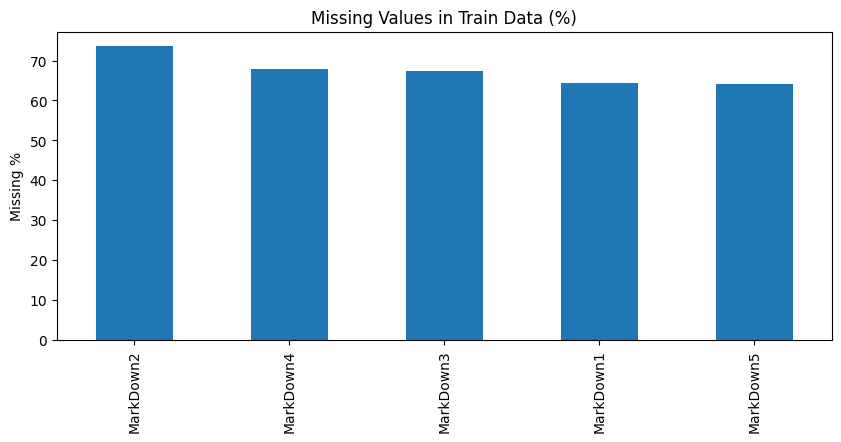

In [15]:
import matplotlib.pyplot as plt
# from pathlib import Path
missing_percent = train_full.isna().mean().sort_values(ascending=False) * 100

missing_percent[missing_percent > 0].plot(kind="bar", figsize=(10, 4))
plt.title("Missing Values in Train Data (%)")
plt.ylabel("Missing %")
plt.show()

# Weekly_Sales distribution

In [16]:
train_full["Weekly_Sales"].describe()

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

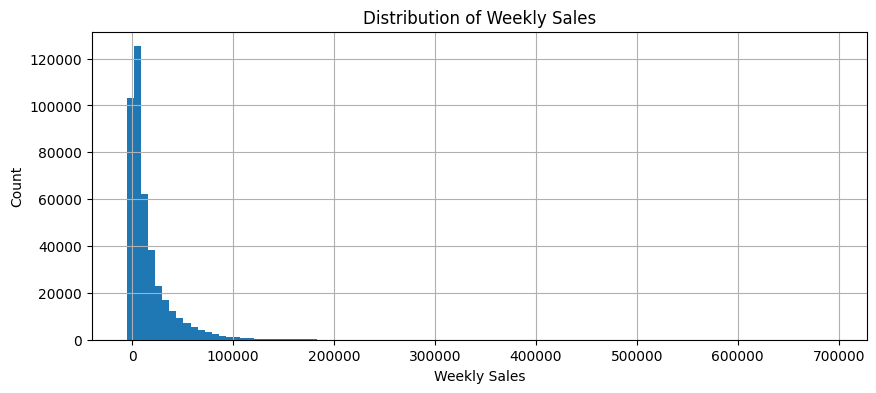

In [17]:
plt.figure(figsize=(10, 4))
train_full["Weekly_Sales"].hist(bins=100)
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Count")
plt.show()

In [18]:
negative_sales = train_full[train_full["Weekly_Sales"] < 0]
print("Negative sales rows:", negative_sales.shape[0])
display(negative_sales.head())

Negative sales rows: 1285


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
846,1,6,2012-08-10,-139.65,False,85.05,3.494,11436.22,245.0,6.85,6964.26,4836.22,221.958433,6.908,A,151315
2384,1,18,2012-05-04,-1.27,False,75.55,3.749,21290.13,NaN,69.89,4977.35,3261.04,221.671800,7.143,A,151315
6048,1,47,2010-02-19,-863.00,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
6049,1,47,2010-03-12,-698.00,False,57.79,2.667,NaN,NaN,NaN,NaN,NaN,211.380643,8.106,A,151315
6051,1,47,2010-10-08,-58.00,False,63.93,2.633,NaN,NaN,NaN,NaN,NaN,211.746754,7.838,A,151315


# Total Weekly Sales over Time


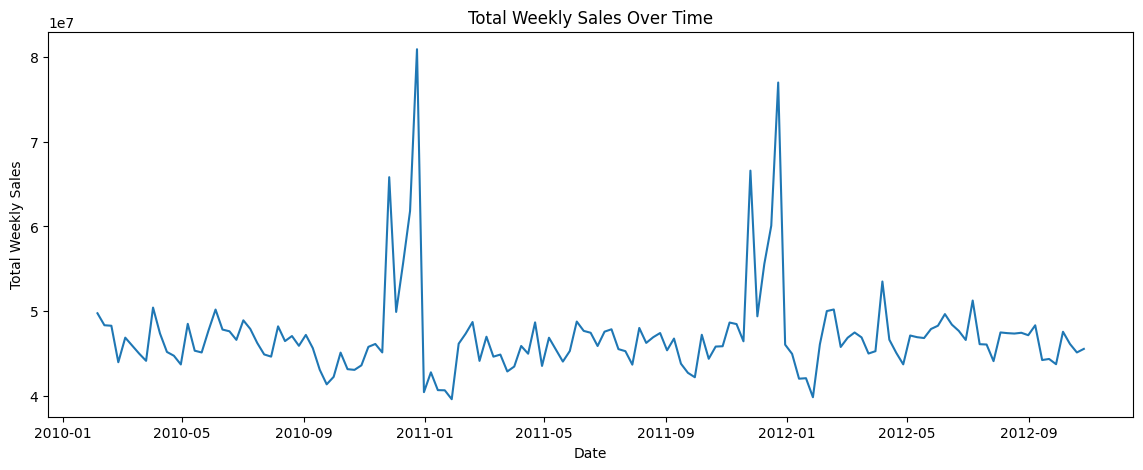

In [19]:
weekly_sales = train_full.groupby("Date")["Weekly_Sales"].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(weekly_sales["Date"], weekly_sales["Weekly_Sales"])
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.show()

# Holiday vs Non-Holiday გაყიდვების რიცხვითი შედარება


In [20]:
holiday_sales = train_full.groupby("IsHoliday")["Weekly_Sales"].agg(
    ["count", "mean", "median", "sum"]
)

holiday_sales

,count,mean,median,sum
IsHoliday,,,,
False,391909,15901.445069,7589.95,6.231919e+09
True,29661,17035.823187,7947.74,5.052996e+08


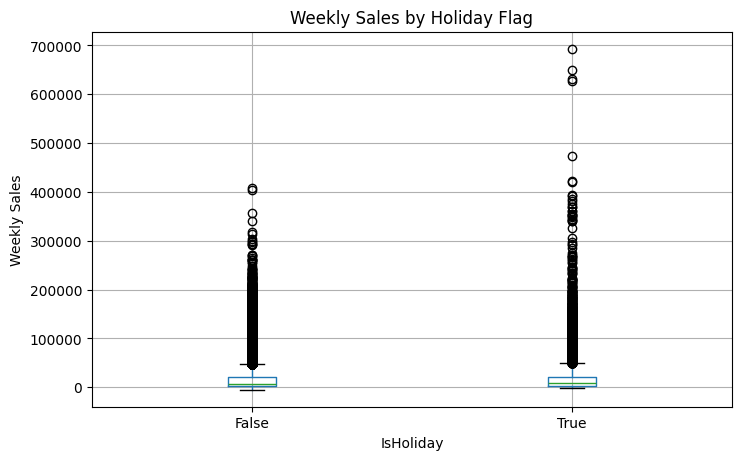

In [21]:
train_full.boxplot(column="Weekly_Sales", by="IsHoliday", figsize=(8, 5))
plt.title("Weekly Sales by Holiday Flag")
plt.suptitle("")
plt.xlabel("IsHoliday")
plt.ylabel("Weekly Sales")
plt.show()

# Store Type-ის მიხედვით გაყიდვების შეჯამება


In [22]:
store_summary = train_full.groupby("Type")["Weekly_Sales"].agg(
    ["count", "mean", "median", "sum"]
).sort_values("sum", ascending=False)

store_summary

,count,mean,median,sum
Type,,,,
A,215478,20099.568043,10105.17,4.331015e+09
B,163495,12237.075977,6187.87,2.000701e+09
C,42597,9519.532538,1149.67,4.055035e+08


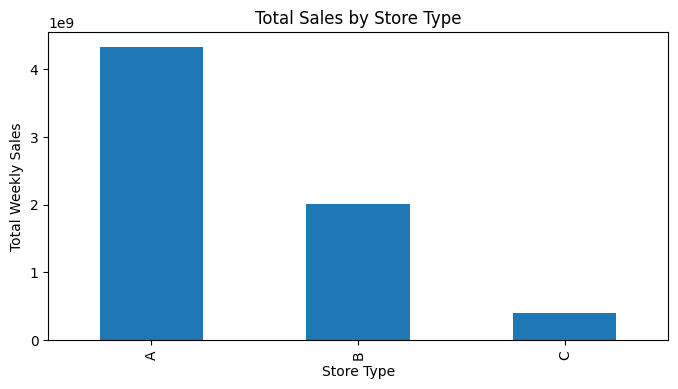

In [23]:
plt.figure(figsize=(8, 4))
train_full.groupby("Type")["Weekly_Sales"].sum().plot(kind="bar")
plt.title("Total Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Total Weekly Sales")
plt.show()

# Store Size და Total Sales კავშირი


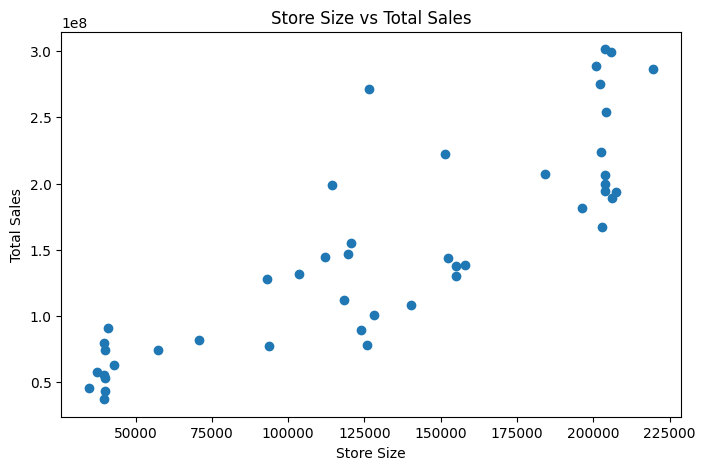

In [24]:
store_size_sales = train_full.groupby("Store").agg(
    total_sales=("Weekly_Sales", "sum"),
    avg_sales=("Weekly_Sales", "mean"),
    size=("Size", "first"),
    type=("Type", "first")
).reset_index()

plt.figure(figsize=(8, 5))
plt.scatter(store_size_sales["size"], store_size_sales["total_sales"])
plt.title("Store Size vs Total Sales")
plt.xlabel("Store Size")
plt.ylabel("Total Sales")
plt.show()

# Department-level sales ანალიზი
შემდეგში `Dept` უნდა შევიტანოთ მოდელში categorical/identifier feature-ად. Neural models-ისთვის შეიძლება embedding გამოყენება, tree-based models-ისთვის კი categorical encoding/target encoding/one-hot encoding.

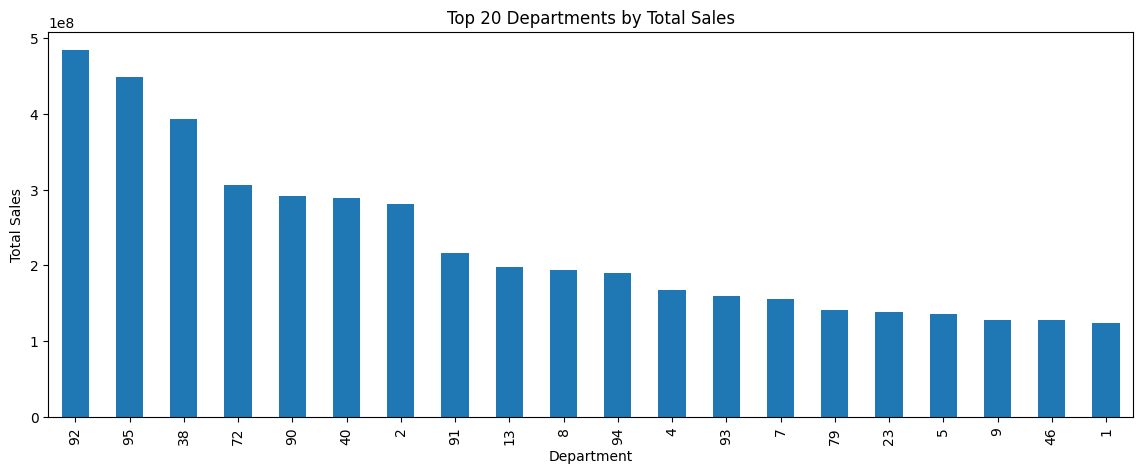

In [25]:
dept_sales = train_full.groupby("Dept")["Weekly_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
dept_sales.head(20).plot(kind="bar")
plt.title("Top 20 Departments by Total Sales")
plt.xlabel("Department")
plt.ylabel("Total Sales")
plt.show()

# Store-Dept time-series რაოდენობა

ეს cell ითვლის უნიკალურ `Store + Dept` კომბინაციებს.

**რა ინფორმაცია მივიღეთ:** გვაქვს 3,331 ცალკე Store-Dept time-series.

**რატომ მნიშვნელოვანია:** ამოცანა არ არის ერთი დიდი time-series. სინამდვილეში გვაქვს 3,331 პატარა series, რომელთა თითოეულისთვის უნდა პროგნოზირდეს მომავალი კვირები.

**როგორ გამოვიყენებთ:** forecasting მოდელებისთვის უნდა გადავწყვიტოთ: თითო სერიაზე ცალკე მოდელი ავაწყოთ თუ global model, რომელიც ყველა series-ზე ერთად სწავლობს. LightGBM/XGBoost-ისთვის ხშირად global tabular model კარგი baseline-ია.

In [26]:
n_series = train_full.groupby(["Store", "Dept"]).size().shape[0]
print("Number of Store-Dept time series:", n_series)

Number of Store-Dept time series: 3331


# Time-based features-ის შექმნა
ეს feature-ები მოდელს ეხმარება seasonal pattern-ების სწავლაში. მომავალში შეიძლება დავამატოთ `quarter`, `is_month_end`, holiday distance და lag features.


In [27]:
train_full["Year"] = train_full["Date"].dt.year
train_full["Month"] = train_full["Date"].dt.month
train_full["Week"] = train_full["Date"].dt.isocalendar().week.astype(int)

# Monthly sales trend
გაყიდვები seasonal behavior-ს აჩვენებს და ამიტომ დროითი feature-ები/forecasting არქიტექტურები საჭიროა.


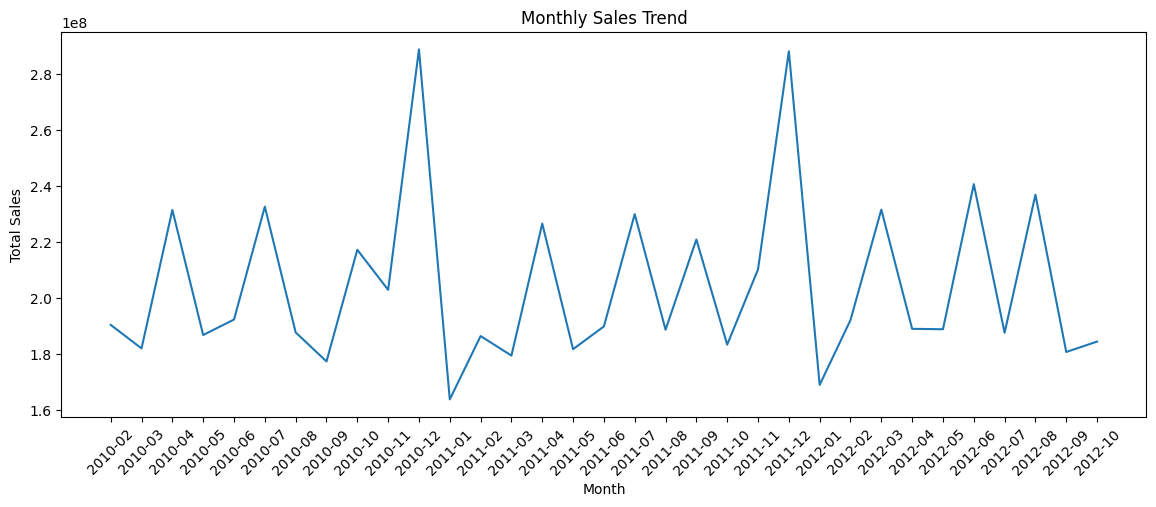

In [28]:
monthly_sales = train_full.groupby(["Year", "Month"])["Weekly_Sales"].sum().reset_index()
monthly_sales["YearMonth"] = monthly_sales["Year"].astype(str) + "-" + monthly_sales["Month"].astype(str).str.zfill(2)

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales["YearMonth"], monthly_sales["Weekly_Sales"])
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

# Average sales by week of year

**როგორ გამოვიყენებთ:** `Week` feature აუცილებლად უნდა შევინარჩუნოთ. ასევე შეიძლება cyclical encoding (`sin_week`, `cos_week`) გამოვიყენოთ neural ან linear models-ში, რადგან week 52 და week 1 რეალურად ერთმანეთთან ახლოსაა.

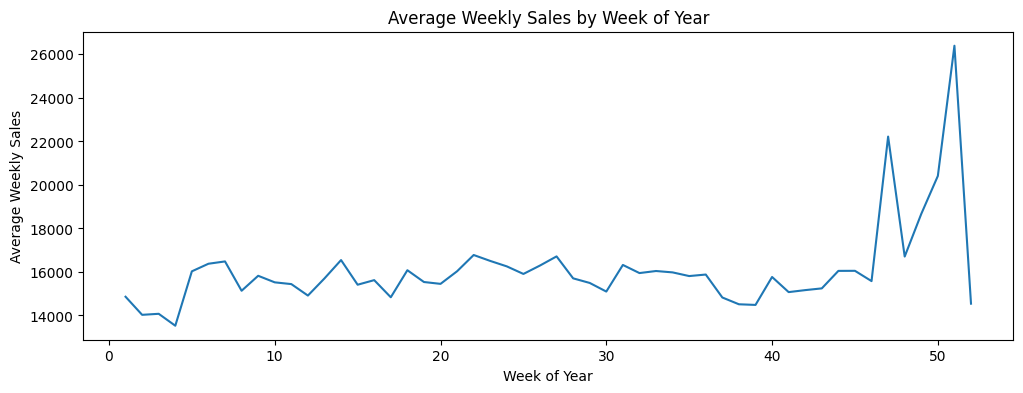

In [29]:
week_sales = train_full.groupby("Week")["Weekly_Sales"].mean()

plt.figure(figsize=(12, 4))
week_sales.plot()
plt.title("Average Weekly Sales by Week of Year")
plt.xlabel("Week of Year")
plt.ylabel("Average Weekly Sales")
plt.show()

# Numeric feature-ების კორელაცია Weekly_Sales-თან


In [30]:
numeric_cols = train_full.select_dtypes(include=["int64", "float64", "bool"]).columns
corr = train_full[numeric_cols].corr(numeric_only=True)["Weekly_Sales"].sort_values(ascending=False)

corr

Weekly_Sales    1.000000
Size            0.243828
Dept            0.148032
MarkDown5       0.090362
MarkDown1       0.085251
MarkDown3       0.060385
MarkDown4       0.045414
Week            0.027673
MarkDown2       0.024130
IsHoliday       0.012774
Fuel_Price     -0.000120
Temperature    -0.002312
CPI            -0.020921
Unemployment   -0.025864
Store          -0.085195
Name: Weekly_Sales, dtype: float64

# Correlation matrix heatmap


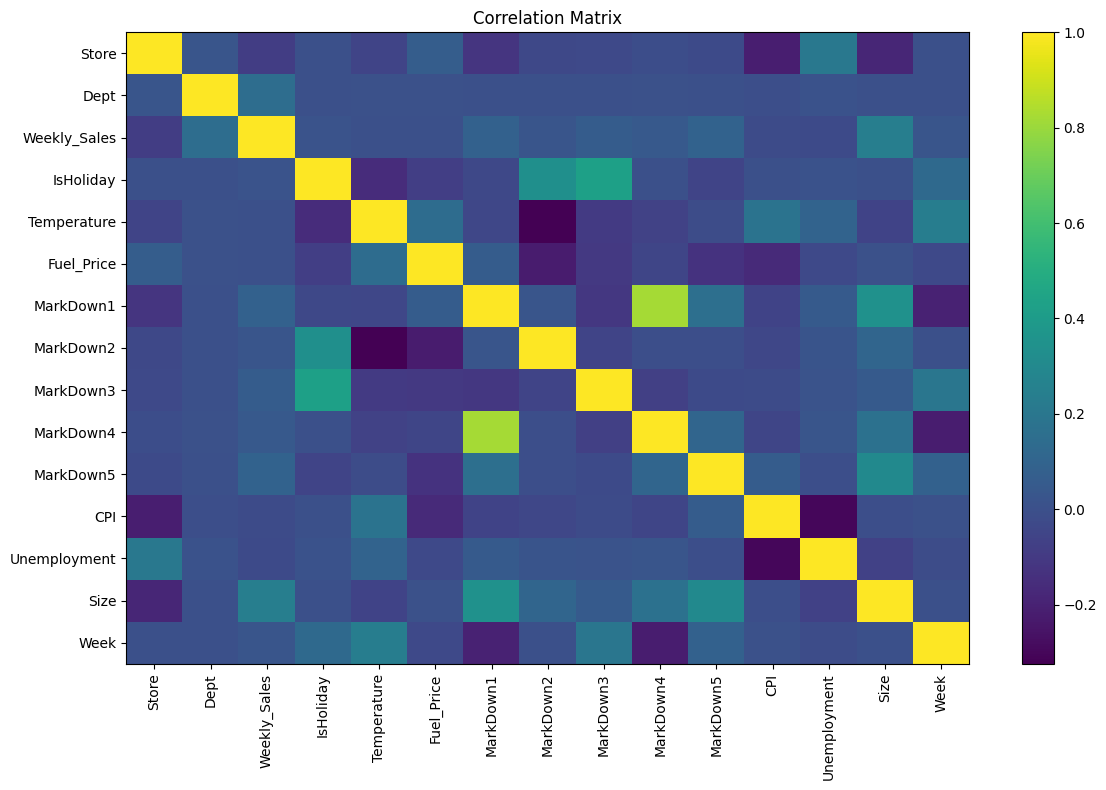

In [31]:
corr_matrix = train_full[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# MarkDown feature-ების აღწერითი სტატისტიკა


In [32]:
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

train_full[markdown_cols].describe()

,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
count,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000
mean,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079
std,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455
min,0.270000,-265.760000,-29.100000,0.220000,135.160000
25%,2240.270000,41.600000,5.080000,504.220000,1878.440000
50%,5347.450000,192.000000,24.600000,1481.310000,3359.450000
75%,9210.900000,1926.940000,103.990000,3595.040000,5563.800000
max,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000


# MarkDown missing percentage


In [33]:
train_full[markdown_cols].isna().mean() * 100

MarkDown1    64.257181
MarkDown2    73.611025
MarkDown3    67.480845
MarkDown4    67.984676
MarkDown5    64.079038
dtype: float64

# 30. MarkDown existence indicator-ის შექმნა

ამ cell-ში თითო markdown column-ისთვის იქმნება ახალი binary feature: `MarkDownX_exists`.

**რას ნიშნავს:**

- 0 — markdown value missing იყო
- 1 — markdown value მოცემული იყო


In [34]:
for col in markdown_cols:
    train_full[col + "_exists"] = train_full[col].notna().astype(int)

markdown_effect = train_full.groupby("MarkDown1_exists")["Weekly_Sales"].agg(["count", "mean", "median"])
markdown_effect

,count,mean,median
MarkDown1_exists,,,
0,270889,15850.967664,7639.67
1,150681,16215.489727,7565.37


In [35]:
for col in markdown_cols:
    exists_col = col + "_exists"
    result = train_full.groupby(exists_col)["Weekly_Sales"].agg(["count", "mean", "median"])
    print("\n", col)
    display(result)


 MarkDown1


,count,mean,median
MarkDown1_exists,,,
0,270889,15850.967664,7639.67
1,150681,16215.489727,7565.37



 MarkDown2


,count,mean,median
MarkDown2_exists,,,
0,310322,15597.599283,7448.530
1,111248,17051.459643,8065.815



 MarkDown3


,count,mean,median
MarkDown3_exists,,,
0,284479,15617.605285,7484.78
1,137091,16735.878016,7893.15



 MarkDown4


,count,mean,median
MarkDown4_exists,,,
0,286603,15489.089487,7356.62
1,134967,17026.380321,8154.14



 MarkDown5


,count,mean,median
MarkDown5_exists,,,
0,270138,15871.522017,7654.845
1,151432,16177.015244,7537.870


# Competition metric — Weighted Mean Absolute Error

`WMAE = sum(weight * abs(y_true - y_pred)) / sum(weight)`

In [36]:
def weighted_mae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

# Naive Store-Dept Mean Baseline


In [37]:
# simple baseline: mean sales per Store-Dept
baseline = train_full.groupby(["Store", "Dept"])["Weekly_Sales"].mean().reset_index()
baseline = baseline.rename(columns={"Weekly_Sales": "baseline_pred"})

train_baseline = train_full.merge(baseline, on=["Store", "Dept"], how="left")

score = weighted_mae(
    train_baseline["Weekly_Sales"],
    train_baseline["baseline_pred"],
    train_baseline["IsHoliday"]
)

print("Naive Store-Dept Mean Baseline WMAE:", score)

Naive Store-Dept Mean Baseline WMAE: 2935.264252368474


# Time-based train/validation split

ეს cell train data-ს თარიღის მიხედვით ალაგებს და ბოლო 3 თვეს validation set-ად ტოვებს.

- train_part: 2010-02-05 → 2012-07-20
- valid_part: 2012-07-27 → 2012-10-26
- train_part rows: 380,107
- valid_part rows: 41,463

**რატომ არ ვიყენებთ random split-ს:** time-series forecasting-ში წარსულით უნდა ვიწინასწარმეტყველოთ მომავალი. Random split შეიძლება მომავლის ინფორმაცია train-ში შეიტანოს და validation score არარეალურად კარგი გამოვიდეს.


In [38]:
train_full = train_full.sort_values("Date")

cutoff_date = train_full["Date"].max() - pd.DateOffset(months=3)

train_part = train_full[train_full["Date"] <= cutoff_date]
valid_part = train_full[train_full["Date"] > cutoff_date]

print("Train period:", train_part["Date"].min(), "→", train_part["Date"].max())
print("Valid period:", valid_part["Date"].min(), "→", valid_part["Date"].max())
print(train_part.shape, valid_part.shape)


Train period: 2010-02-05 00:00:00 → 2012-07-20 00:00:00
Valid period: 2012-07-27 00:00:00 → 2012-10-26 00:00:00
(380107, 24) (41463, 24)


# EDA-ის მთავარი დასკვნები

## Walmart Store Sales Forecasting dataset-ის საწყისი EDA. 

მონაცემები შედგება 45 store-ისგან და 3,331 უნიკალური `Store + Dept` time-series-ისგან. ეს ნიშნავს, რომ ამოცანა არ არის ერთი დროითი მწკრივის პროგნოზირება; საჭიროა ბევრი store-department კომბინაციის მომავალი weekly sales-ის პროგნოზი.

`train` პერიოდი ფარავს 2010-02-05-დან 2012-10-26-მდე, ხოლო `test` იწყება 2012-11-02-დან და გრძელდება 2013-07-26-მდე. ამიტომ validation split უნდა გაკეთდეს დროის მიხედვით და არა random-ად.

Target variable `Weekly_Sales` skewed distribution-ს აჩვენებს: median საშუალოზე ბევრად დაბალია, რაც ნიშნავს, რომ ბევრია დაბალი/საშუალო გაყიდვა და ცოტაა ძალიან მაღალი გაყიდვები. ასევე დაფიქსირდა 1,285 უარყოფითი sales row, რაც შეიძლება returns/refunds/corrections-ს უკავშირდებოდეს.

Holiday კვირები მნიშვნელოვანია, რადგან Kaggle metric-ში მათ 5-ჯერ მეტი წონა აქვს. EDA-მ აჩვენა, რომ holiday weeks საშუალოდ უფრო მაღალი sales-ისაა, მაგრამ ეფექტი სრულად არ აიხსნება მხოლოდ `IsHoliday` feature-ით. სავარაუდოდ საჭიროა holiday type, week-of-year და department/store interaction-ების გამოყენება.

Store-level ანალიზმა აჩვენა, რომ `Type A` stores ყველაზე დიდ total და average sales-ს უკავშირდება, ხოლო store `Size` positive correlation-ს აჩვენებს sales-თან. Department-level ანალიზმა აჩვენა, რომ department-ებს შორის sales scale ძალიან განსხვავებულია. ამიტომ `Store`, `Dept`, `Type`, `Size` მნიშვნელოვანი features იქნება.

Markdown columns-ში ბევრი missing value აღმოჩნდა, რაც dataset-ის აღწერას შეესაბამება: markdown data მხოლოდ 2011 წლის ნოემბრის შემდეგაა ხელმისაწვდომი და არა ყველა store/week-ისთვის. ამიტომ markdown missing values არ უნდა წავშალოთ. უკეთესი strategy იქნება missing values-ის 0-ით შევსება და `MarkDownX_exists` indicator feature-ების დამატება.

საწყისი baseline-ად დაითვალა `Store + Dept` historical mean prediction, რომელმაც train-ზე WMAE ≈ 2935.26 მიიღო. ეს score მხოლოდ reference-ია, რადგან train-ზეა დათვლილი. შემდეგ ეტაპზე baseline და ყველა მოდელი უნდა შეფასდეს time-based validation set-ზე.

